In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np


In [3]:
# Load data
df = pd.read_csv('blind_discrimination_results.csv', sep=';')

# Display first rows and info
print("=== Data Preview ===")
print(df.head())
print("\n=== Data Types ===")
print(df.dtypes)

# Descriptive statistics
print("\n=== Descriptive Statistics ===")
print(df.describe())


=== Data Preview ===
       session_id  evaluator_id evaluator_name image_id    image_filename  \
0  BLIND_2026_001             1       Expert_1  IMG_043  tgs_real_043.png   
1  BLIND_2026_001             1       Expert_1  IMG_042  tgs_real_042.png   
2  BLIND_2026_001             1       Expert_1  IMG_092   control_002.png   
3  BLIND_2026_001             1       Expert_1  IMG_010  tgs_real_010.png   
4  BLIND_2026_001             1       Expert_1  IMG_066     synth_021.png   

  image_source_ground_truth  random_order       shown_timestamp  \
0                      real             1  2026-09-11T11:20:00Z   
1                      real             2  2026-09-11T13:35:00Z   
2                   control             3  2026-09-11T04:24:00Z   
3                      real             4  2026-09-11T09:01:00Z   
4                 synthetic             5  2026-09-11T21:25:00Z   

  predicted_source segmentation_mask_file  segmentation_done  precision  \
0             real      mask_real_043.

In [9]:
# Descritivas por Expert e por tipo de imagem (real vs synthetic)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for source, src_group in df.groupby('image_source_ground_truth'):
    print(f"\n{'='*60}")
    print(f"  Source: {source.upper()}")
    print(f"{'='*60}")
    for expert, exp_group in src_group.groupby('evaluator_name'):
        print(f"\n  --- Expert: {expert} ---")
        print(exp_group[numeric_cols].describe())



  Source: CONTROL

  --- Expert: Expert_1 ---
       evaluator_id  random_order  segmentation_done  precision  recall  \
count          10.0     10.000000               10.0        0.0     0.0   
mean            1.0     53.000000                0.0        NaN     NaN   
std             0.0     31.347515                0.0        NaN     NaN   
min             1.0      3.000000                0.0        NaN     NaN   
25%             1.0     27.250000                0.0        NaN     NaN   
50%             1.0     60.000000                0.0        NaN     NaN   
75%             1.0     73.500000                0.0        NaN     NaN   
max             1.0     97.000000                0.0        NaN     NaN   

       f1_score  
count       0.0  
mean        NaN  
std         NaN  
min         NaN  
25%         NaN  
50%         NaN  
75%         NaN  
max         NaN  

  --- Expert: Expert_2 ---
       evaluator_id  random_order  segmentation_done  precision  recall  \
count       

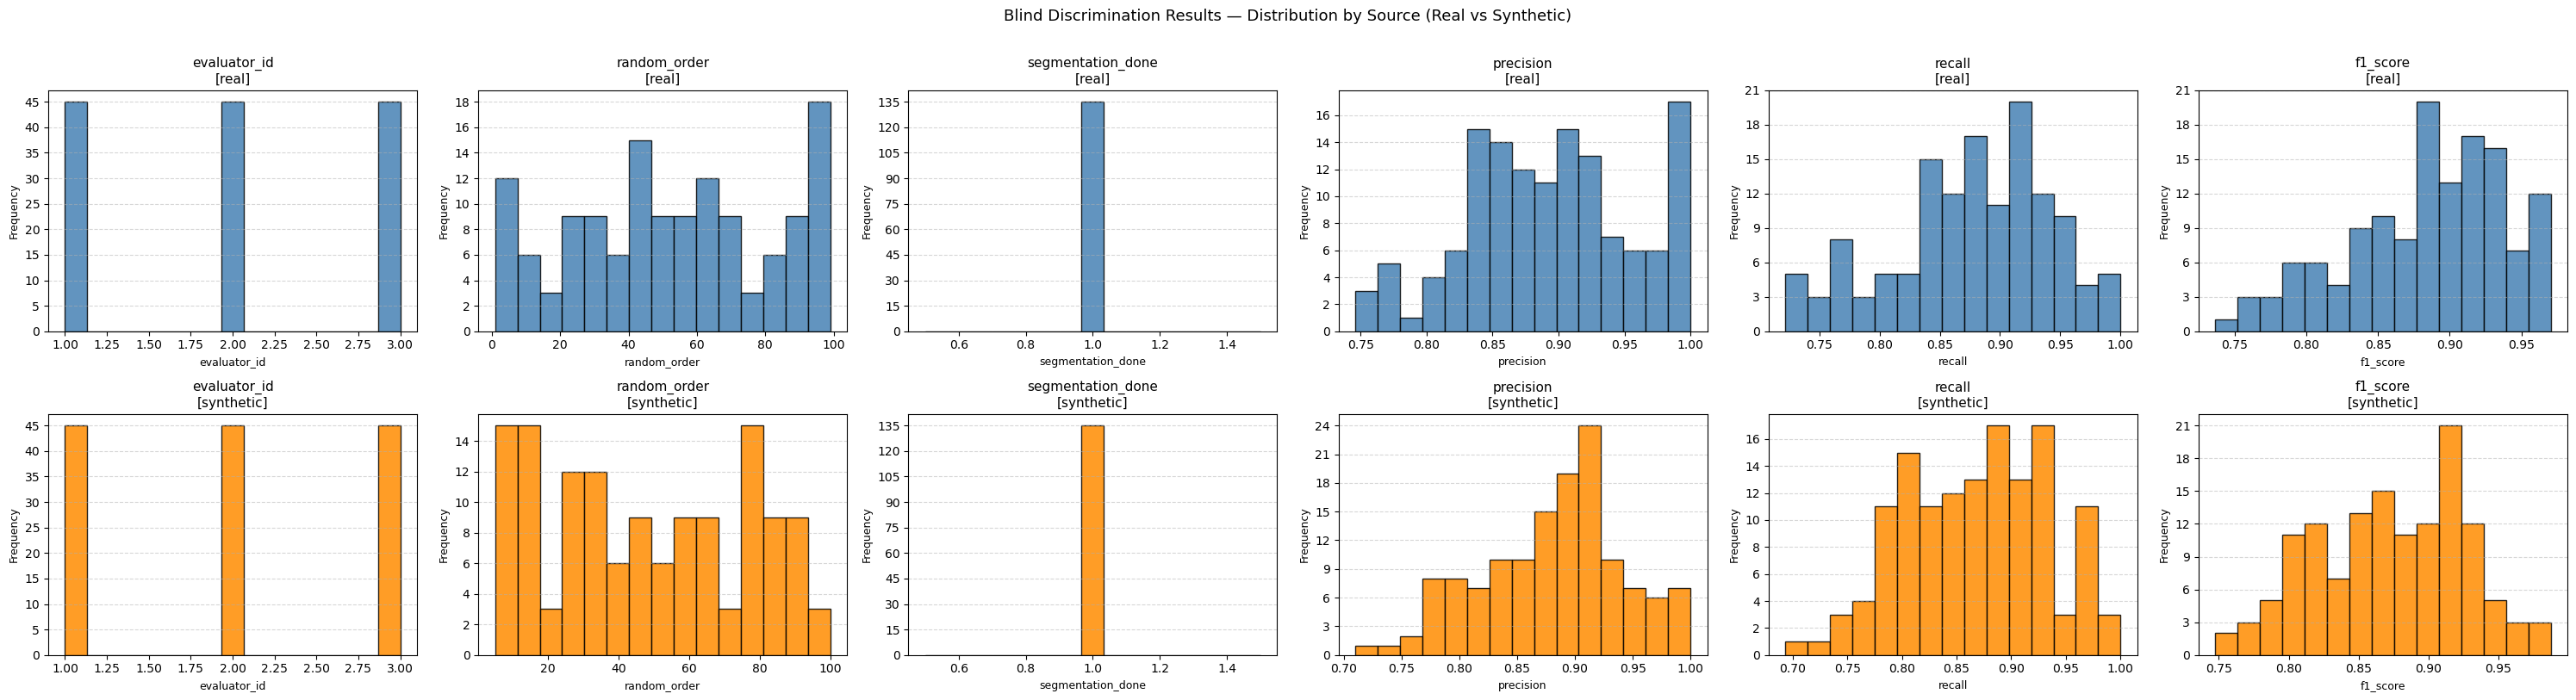

Histogram saved.


In [10]:
# Histogramas por tipo de imagem (real vs synthetic) — exclui 'control'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
sources = [s for s in df['image_source_ground_truth'].unique() if s != 'control']
colors = {'real': 'steelblue', 'synthetic': 'darkorange'}

fig, axes = plt.subplots(len(sources), len(numeric_cols),
                         figsize=(5 * len(numeric_cols), 4 * len(sources)),
                         squeeze=False)

for row, source in enumerate(sources):
    subset = df[df['image_source_ground_truth'] == source]
    for col_idx, col in enumerate(numeric_cols):
        ax = axes[row][col_idx]
        ax.hist(subset[col].dropna(), bins=15,
                color=colors.get(source, 'gray'), edgecolor='black', alpha=0.85)
        ax.set_title(f'{col}\n[{source}]', fontsize=11)
        ax.set_xlabel(col, fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Blind Discrimination Results — Distribution by Source (Real vs Synthetic)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('blind_discrimination_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Histogram saved.")
